# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

Who: A retail business manager or data analyst at an e-commerce company who needs to understand sales performance, profitability, and fulfillment patterns across the US. <br>
What: Online retail has a paradox of choice problem. A typical e-commerce platform carries tens of thousands of SKUs, and the average shopper has limited patience. Without intelligent filtering, customers either abandon their session from frustration or settle for a product that doesn't quite fit. Meanwhile, retailers are sitting on enormous quantities of behavioral data that largely goes unused. A smarter recommendation engine bridges that gap. Key qusitons include which kinds of customers are more profitable and where are they located? What are they buying? When are they buying more? <br>
How: You do some exploratory data anlysis and determine how profit flactuates. You can create clusters for your custoemrs. Example, a bar chart comparing average profit by discount tier, with bars colored red for discount levels that on average produce negative profit, making the loss threshold immediately visible to a non-technical manager.

# 3. Homework - work with your own data

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

The data set of choice is the US E-Commerce Records 2020 dataset, a transactional order log covering the full calendar year 2020 from January 1st to December 30th. It represents a single US-based online retail operation selling across three broad categories: Furniture, Office Supplies, and Technology. 

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('US Commerce', encoding='latin1')
df.head()

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,01-01-20,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,01-01-20,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,01-01-20,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,01-01-20,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,01-01-20,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3312 non-null   str    
 1   Row ID        3312 non-null   int64  
 2   Order ID      3312 non-null   str    
 3   Ship Mode     3312 non-null   str    
 4   Customer ID   3312 non-null   str    
 5   Segment       3312 non-null   str    
 6   Country       3312 non-null   str    
 7   City          3312 non-null   str    
 8   State         3312 non-null   str    
 9   Postal Code   3312 non-null   int64  
 10  Region        3312 non-null   str    
 11  Product ID    3312 non-null   str    
 12  Category      3312 non-null   str    
 13  Sub-Category  3312 non-null   str    
 14  Product Name  3312 non-null   str    
 15  Sales         3312 non-null   float64
 16  Quantity      3312 non-null   int64  
 17  Discount      3312 non-null   float64
 18  Profit        3312 non-null   float64
d

In [9]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,3312.000000,3312.000000,3312.000000,3312.000000,3312.000000,3312.000000
mean,5087.107488,56186.515097,221.381418,3.766908,0.156467,28.212340
std,2817.482266,31980.375516,585.257531,2.221776,0.207429,241.864342
min,13.000000,1841.000000,0.444000,1.000000,0.000000,-3839.990400
25%,2655.750000,27978.750000,17.018000,2.000000,0.000000,1.763200
50%,5183.500000,60472.500000,53.810000,3.000000,0.200000,8.296800
75%,7498.250000,90032.000000,205.105700,5.000000,0.200000,28.315125
max,9994.000000,99301.000000,13999.960000,14.000000,0.800000,6719.980800


In [10]:
print(f"Duplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


Result: 0 duplicate rows. The data is clean in this respect.

In [ ]:
# Order ID appears multiple times since one order can have multiple products
print(f"Unique Order IDs: {df['Order ID'].nunique()} out of {len(df)} rows")

# Row ID should be unique
print(f"Unique Row IDs: {df['Row ID'].nunique()} out of {len(df)} rows")

Unique Order IDs: 1687 out of 3312 rows
Unique Row IDs: 3312 out of 3312 rows


Each row in the dataset is a line item (one product within one order), not an order itself. 

In [12]:
print(df.isnull().sum())


Order Date      0
Row ID          0
Order ID        0
Ship Mode       0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Product ID      0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


Result: No null values in any column. The dataset is complete. 

In [13]:
for col in ['Sales', 'Quantity', 'Discount', 'Profit']:
    print(f"{col}:")
    print(f"  Mean:   {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    print(f"  Mode:   {df[col].mode()[0]:.2f}")

Sales:
  Mean:   221.38
  Median: 53.81
  Mode:   12.96
Quantity:
  Mean:   3.77
  Median: 3.00
  Mode:   2.00
Discount:
  Mean:   0.16
  Median: 0.20
  Mode:   0.00
Profit:
  Mean:   28.21
  Median: 8.30
  Mode:   0.00


In [15]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=False)
print(f"Date range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")

Date range: 2020-01-01 to 2020-12-30


In [16]:
# Encode Ship Mode, Segment, Category, and Region
df_encoded = df.copy()

for col in ['Ship Mode', 'Segment', 'Category', 'Region']:
    one_hot = pd.get_dummies(df_encoded[col], prefix=col)
    df_encoded = df_encoded.join(one_hot)

# Convert boolean columns to int
ohe_cols = [c for c in df_encoded.columns if any(
    c.startswith(p) for p in ['Ship Mode_', 'Segment_', 'Category_', 'Region_'])]
df_encoded[ohe_cols] = df_encoded[ohe_cols].astype(int)

print(f"New shape: {df_encoded.shape}")
print(df_encoded[ohe_cols].head())

New shape: (3312, 33)
   Ship Mode_First Class  Ship Mode_Same Day  Ship Mode_Second Class  \
0                      0                   0                       0   
1                      0                   0                       0   
2                      1                   0                       0   
3                      0                   0                       0   
4                      0                   0                       0   

   Ship Mode_Standard Class  Segment_Consumer  Segment_Corporate  \
0                         1                 1                  0   
1                         1                 1                  0   
2                         0                 0                  0   
3                         1                 1                  0   
4                         1                 1                  0   

   Segment_Home Office  Category_Furniture  Category_Office Supplies  \
0                    0                   1                      

The data is clean and usable. Key conclusions:

No missing values, no duplicate rows — no cleaning required. <br>
The Country column is redundant (all United States) and can be dropped. <br>
18.7% of orders lose money, primarily driven by deep discounts (≥60%). This is fine and can help us uncover what's going on here. <br>
Sales is heavily right-skewed. This is fine since we're dealing with real transaction data. <br>


# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

I will be reproducing the Average Retail Product Price per Year graph. 

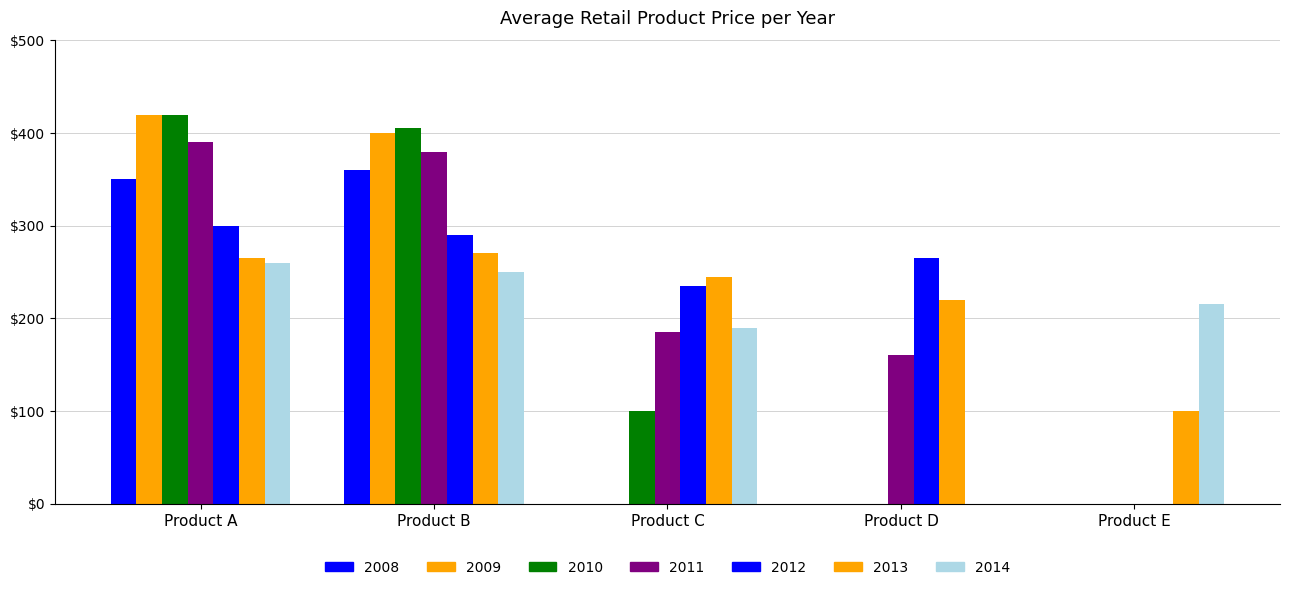

In [18]:

years = ['2008', '2009', '2010', '2011', '2012', '2013', '2014']
colors = ['blue', 'orange', 'green', 'purple', 'blue', 'orange', 'lightblue']

data = {
    'Product A': [350, 420, 420, 390, 300, 265, 260],
    'Product B': [360, 400, 405, 380, 290, 270, 250],
    'Product C': [None, None, 100, 185, 235, 245, 190],
    'Product D': [None, None, None, 160, 265, 220, None],
    'Product E': [None, None, None, None, None, 100, 215],
}

products = list(data.keys())
n_products = len(products)
n_years = len(years)
bar_width = 0.11
x = np.arange(n_products)

fig, ax = plt.subplots(figsize=(13, 6))

for i, (year, color) in enumerate(zip(years, colors)):
    values = [data[p][i] if data[p][i] is not None else 0 for p in products]
    offsets = x + (i - n_years / 2 + 0.5) * bar_width
    bars = ax.bar(offsets, values, width=bar_width, label=year, color=color)

    # Hide bars with no data (value was None) by making them invisible
    for bar, val in zip(bars, [data[p][i] for p in products]):
        if val is None:
            bar.set_visible(False)

ax.set_title('Average Retail Product Price per Year', fontsize=13, pad=12)
ax.set_xticks(x)
ax.set_xticklabels(products, fontsize=11)
ax.set_ylim(0, 500)
ax.set_yticks([0, 100, 200, 300, 400, 500])
ax.set_yticklabels(['$0', '$100', '$200', '$300', '$400', '$500'])
ax.yaxis.grid(True, color='lightgray', linewidth=0.7)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.18), ncol=7,
          frameon=False, fontsize=10,
          handles=[plt.Rectangle((0,0),1,1, color=c) for c in colors],
          labels=years)

plt.tight_layout()
plt.show()